In [1]:
import torch
import hdf5plugin
import h5py
from omegaconf import OmegaConf

from transformers import AutoImageProcessor, AutoModel

from sequence_compression.eval.observation_decoder import CLSDecoder
from sequence_compression.eval.eval import build_model_pipeline

from tqdm import tqdm

from matplotlib import pyplot as plt
import numpy as np

In [2]:
h5_path = "../data/pusht_expert_train.h5"
config_path = "../config/transpressor_baseline.yaml"
checkpoint = "../checkpoints/lewm_epoch_8.pt"
device = "mps"

cfg = OmegaConf.load(config_path)
model, preprocessor = build_model_pipeline(cfg, checkpoint, device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

decoder = CLSDecoder(
    model.pixel_encoder.config.hidden_size
).to(device)

with h5py.File(h5_path, "r") as data:
    # Sample 100 unique datapoints from dataset
    embeddings = []

    action_arr = data["action"][:]  # load once; h5py fancy-indexing per-row is slow
    pixels_arr = data["pixels"][:]
    starts = np.random.randint(0, len(action_arr) - 10, size=10)

    actions = torch.tensor(np.stack([np.asarray(action_arr[s:s + 10]) for s in starts], axis=0)).to("mps")  # (10, 10, 2)
    pixels = torch.tensor(np.stack([np.asarray(pixels_arr[s:s + 10:5]) for s in starts], axis=0)).to("mps") # (10, 2, 3, 224, 224)

# Bundle every frameskip=5 consecutive raw actions into one macro-step, concatenated
# along the feature axis (mirrors ChainDataset's frameskip bundling): (B, 10, 2) -> (B, 2, 10).
frameskip = 5
raw_B, raw_T, action_dim = actions.shape
actions = actions.reshape(raw_B, raw_T // frameskip, frameskip * action_dim)

In [3]:
print(f"Pixels shape: {pixels.shape}")
print(f"Actions shape: {actions.shape}")

PB, PT, PH, PW, PC = pixels.shape
AB, AT, AD = actions.shape

Pixels shape: torch.Size([10, 2, 224, 224, 3])
Actions shape: torch.Size([10, 2, 10])


In [4]:
state_dict = torch.load("../checkpoints/decoder_raw_dinov2.pt", map_location=device, weights_only=True)
decoder.load_state_dict(state_dict)

processed = preprocessor(list(pixels.reshape(PB*PT, PH, PW, PC)), return_tensors="pt")["pixel_values"].to("mps")

processed = processed.reshape(PB, PT, PC, PW, PH)
pixel_embs = model.encode_pixels(processed)
action_embs = model.encode_actions(actions)

print(processed.shape)
print(pixel_embs.shape)
print(action_embs.shape)

torch.Size([10, 2, 3, 224, 224])
torch.Size([10, 2, 192])
torch.Size([10, 2, 192])


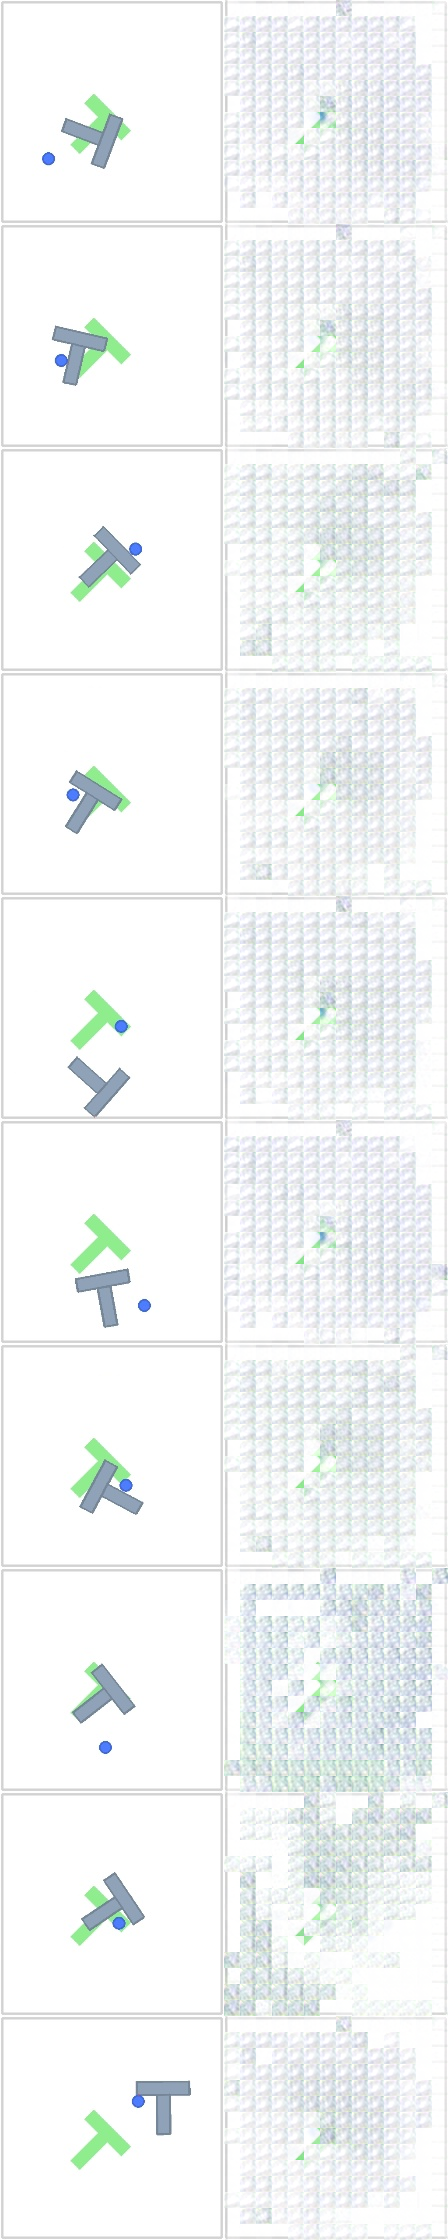

In [5]:
from sequence_compression.eval.observation_decoder import unnormalize, save_reconstructions
from PIL import Image

info = model.predict(processed, actions)

obs = info["obs"]
pred = info["pred"]
target = info["target"]

decoded = decoder(pred.flatten(0, 1)).detach().cpu() # (B, C, H, W) - reconstruction of the predicted next-frame embedding

# pred[i] predicts the embedding of processed[i, 1] (the frame after the one the
# predictor conditioned on), so that's the original to compare each reconstruction against.
originals = processed[:, 1].detach().cpu()

out_path = "rollout_reconstructions.png"
save_reconstructions(originals, decoded, preprocessor, out_path)
Image.open(out_path)